# Reconstruction using Depth Anything v3 Pipeline

## Import Libraries

In [2]:
import glob
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys
import open3d as o3d
sys.path.append("../Depth-Anything-3/src")
from depth_anything_3.api import DepthAnything3

## Environment Setup and Visualization functions

In [3]:
def setup_paths(data_folder="SAMPLE_SCENE"):
    paths = {
        'data': f"{data_folder}/images",
        'results': f"{data_folder}/results",
        'masks': f"{data_folder}/masks",
    }
    os.makedirs(paths['results'], exist_ok=True)
    os.makedirs(paths['masks'], exist_ok=True)
    return paths

def visualize_depth_and_confidence(images, depths, confidences, sample_idx=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(images[sample_idx])
    axes[0].set_title('RGB Image')
    axes[0].axis('off')

    axes[1].imshow(depths[sample_idx], cmap='turbo')
    axes[1].set_title('Depth Map')
    axes[1].axis('off')

    axes[2].imshow(confidences[sample_idx], cmap='viridis')
    axes[2].set_title('Confidence Map')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

def visualize_point_cloud_open3d(points, colors=None, window_name="Point Cloud"):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.visualization.draw_geometries([pcd], window_name=window_name)

In [4]:
paths = setup_paths("../reconstructions/DepthAnything3/")
print(f"Project paths created: {paths}")

Project paths created: {'data': '../reconstructions/DepthAnything3//images', 'results': '../reconstructions/DepthAnything3//results', 'masks': '../reconstructions/DepthAnything3//masks'}


## Load DA3 Model

In [7]:
def load_da3_model(model_name="depth-anything/DA3NESTED-GIANT-LARGE"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = DepthAnything3.from_pretrained(model_name)
    model.to(device)

    return model, device

In [8]:
model, device = load_da3_model()
print("Model loaded successfully.")

Using device: cuda


config.json: 0.00B [00:00, ?B/s]

[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/6.76G [00:00<?, ?B/s]

Model loaded successfully.


## Load Images from folder

In [9]:
def load_images_from_folder(data_path, extensions=[".jpg", ".png", ".jpeg"]):
    image_files = []
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(data_path, f"*{ext}")))
    print(f"Found {len(image_files)} images in {data_path}")
    return image_files

def extract_frames_from_video(video_path, output_folder, sample_rate=3):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % sample_rate == 0:
            output_path = os.path.join(output_folder, f"frame_{saved_count:05d}.png")
            cv2.imwrite(output_path, frame)
            saved_count += 1
        frame_count += 1

    cap.release()
    print(f"Extracted {saved_count} frames to {output_folder}")
    return output_folder

In [10]:
image_files = load_images_from_folder(paths['data'])

Found 20 images in ../reconstructions/DepthAnything3//images


## Run DA3 Inference for Depth and Poses

In [13]:
def run_da3_inference(model, image_files, process_res_method="upper_bound_resize"):
    prediction = model.inference(
        image=image_files,
        infer_gs=True,
        process_res_method=process_res_method
    )

    print(f"Depth maps shape: {prediction.depth.shape}")
    print(f"Extrinsics shape: {prediction.extrinsics.shape}")
    print(f"Intrinsics shape: {prediction.intrinsics.shape}")
    print(f"Confidences shape: {prediction.conf.shape}")

    return prediction

[INFO ] Processed Images Done taking 1.1777782440185547 seconds. Shape:  torch.Size([20, 3, 378, 504])
[INFO ] Selecting reference view using strategy: saddle_balanced
[INFO ] Model Forward Pass Done. Time: 525.3670063018799 seconds
[INFO ] Conversion to Prediction Done. Time: 0.06067466735839844 seconds
Depth maps shape: (20, 378, 504)
Extrinsics shape: (20, 3, 4)
Intrinsics shape: (20, 3, 3)
Confidences shape: (20, 378, 504)


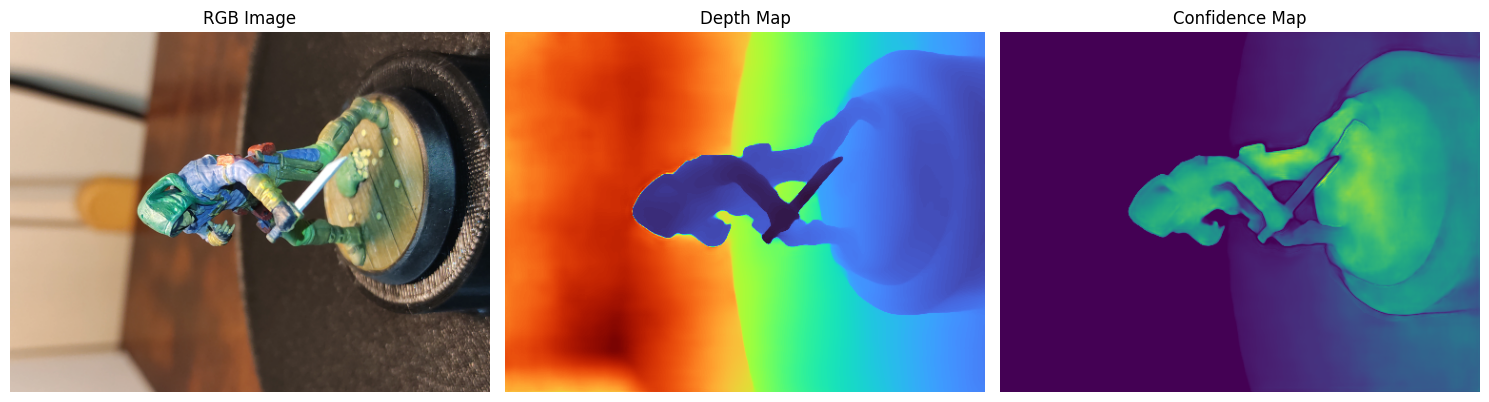

In [14]:
prediction = run_da3_inference(model, image_files)

visualize_depth_and_confidence(
    prediction.processed_images,
    prediction.depth,
    confidences=prediction.conf,
    sample_idx=0
)

## Generate 3D Point Cloud from Depth Maps 

In [15]:
def depth_to_point_cloud(depth_map, rgb_image, intrinsics, extrinsics, conf_map=None, conf_thresh=0.5):
    h, w = depth_map.shape
    fx, fy = intrinsics[0, 0], intrinsics[1, 1]
    cx, cy = intrinsics[0, 2], intrinsics[1, 2]

    u, v = np.meshgrid(np.arange(w), np.arange(h))

    if conf_map is not None:
        mask = conf_map >= conf_thresh
        u, v, depth_map, rgb_image = u[mask], v[mask], depth_map[mask], rgb_image[mask]
    else:
        u, v, depth_map = u.flatten(), v.flatten(), depth_map.flatten()
        rgb_image = rgb_image.reshape(-1, 3)
    
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map

    points_cam = np.stack([x, y, z], axis=-1)

    R = extrinsics[:3, :3]
    t = extrinsics[:3, 3]
    points_world = (points_cam - t) @ R

    colors = rgb_image.astype(np.float32) / 255.0

    return points_world, colors

def merge_point_clouds(prediction, conf_thresh=0.5):
    all_points = []
    all_colors = []

    n_frames = len(prediction.depth)

    for i in range(n_frames):
        points, colors = depth_to_point_cloud(
            prediction.depth[i],
            prediction.processed_images[i],
            prediction.intrinsics[i],
            prediction.extrinsics[i],
            conf_map=prediction.conf[i],
            conf_thresh=conf_thresh
        )
        all_points.append(points)
        all_colors.append(colors)
    
    merged_points = np.vstack(all_points)
    merged_colors = np.vstack(all_colors)

    print(f"Merged point cloud has {len(merged_points)} points.")
    return merged_points, merged_colors

In [ ]:
points_3d, colors_3d = merge_point_clouds(prediction, conf_thresh=0.4)
visualize_point_cloud_open3d(points_3d, colors_3d, window_name="DA3 Merged Point Cloud")

Merged point cloud has 3810240 points.
